# Test 0

In [ ]:
import main2DIR as dd_ir
import numpy as np

# # testing template function for w_mn terms for the whole 2d spectrum tensor
w_all = {'0': 1., '1': 5., '00': 2., '01': 6., '11': 10.}
Gamma = 10 ** (-0.3)
w1, w2 = np.arange(1, 13, 2), np.arange(1, 13, 2)
w1grid, w2grid = np.meshgrid(w1, w2)
fundamentals = {'0': 1., '1': 5.}

test2d = dd_ir.SpectrumEVV(w1, w2, fundamentals, Gamma, False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a'), ('b,a', 'zero,a')]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))],
                 [('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                    [('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                    [('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                    [('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                    [('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                    [('b,a', 'zero,a'), ('b,a+b', 'a,zero')]]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',)), 'bcc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',)), 'acc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',)), 'bcc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',)), 'acc']]

test2d.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)
test2d.combofuns

test2d.gamma_mn(0, 0)

coords_ab = dd_ir.get_abc(2, len(test2d.fundamentals))
test2d.plot2D(coords_ab=coords_ab, coords_abc=[], w1mw2=False)

# Test 1 - CH3CN

In [ ]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

# w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)

funds = {'0':20, '1':30
                , '2':50
               }
# funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))
funds = dict(zip(['0', '1', '2', '3', '4', '5'], [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))

h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
# h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a')
                   # ('b,a', 'zero,a')
                   ]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
                  #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
                ]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                     #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                     #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                     #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# electrical_terms, electric_avrg = [], []
# mechanical_terms, mechanical_avrg = [], []

h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
coords_abc = dd_ir.get_abc(3, len(h.fundamentals))

# print(coords_abc)

# h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)

print(r)
# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)


In [ ]:
print(coords_abc[0])

# Test 2 - H2O and CH3CN

In [ ]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

# w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
w1, w2 = np.arange(1200., 4420, 15), np.arange(2300., 8320, 15)

funds = {'0':20, '1':30
                , '2':50
               }
funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))
# funds = dict(zip(['0', '1', '2', '3', '4', '5'], [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))

# h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a')
                   # ('b,a', 'zero,a')
                   ]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
                  #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
                ]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                     #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                     #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                     #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# electrical_terms, electric_avrg = [], []
# mechanical_terms, mechanical_avrg = [], []

h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
coords_abc = dd_ir.get_abc(3, len(h.fundamentals))

# print(coords_abc)

# h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)

print(r)
# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)


# All new tests

## Symbolic notation for terms

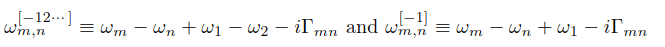

$\omega_1 = \omega_n - \omega_m$


$\omega_2 = \omega_m - \omega_n + \omega_1$

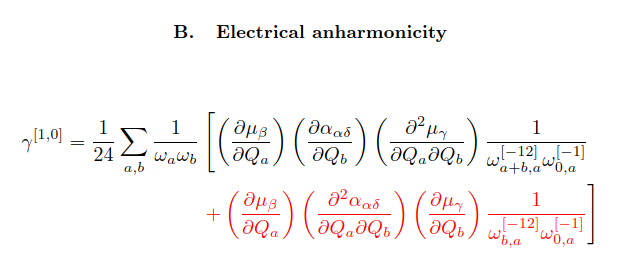

In [ ]:
def get_signals(self, term, mech=False):
    if not mech:
        self.all_states['zero'] = 0.
        
        abstuplesss = self.get_abc(2, len(h.fundamentals))
        for abstuple in abstuplesss:
            letters = ['a', 'b', 'c', 'zero'] if len(abctuple) == 3 else ['a', 'b', 'zero']
            dictabc = dict(zip(letters, abctuple + tuple(['zero'])))

            m1n1m2n2 = [i.split(',') for i in subscripts]
            wm1 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[0][0].split('+')]))
            wn1 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[0][1].split('+')]))
            wm2 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[1][0].split('+')]))
            wn2 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[1][1].split('+')]))
        

In [1]:
# Terms in expressions
electrical_terms = [('a+b,a', 'zero,a')
                   ,('b,a', 'zero,a')
                   ]

electric_avrg = [[ ('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',)) ]
                  ,[ ('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',)) ]
                ]

mechanical_terms = [ [('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')]
                     # ,[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')]
                     # ,[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')]
#                      #,[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
#                      #,[('b,a', 'zero,a'), ('a,a+b', 'b,zero')]
#                      #,[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc']
                    # ,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))]
                    # ,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))]
#                     #,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
#                     #,[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))]
#                     #,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# # electrical_terms, electric_avrg = [], []
mechanical_terms, mechanical_avrg = [], []

## Test 0

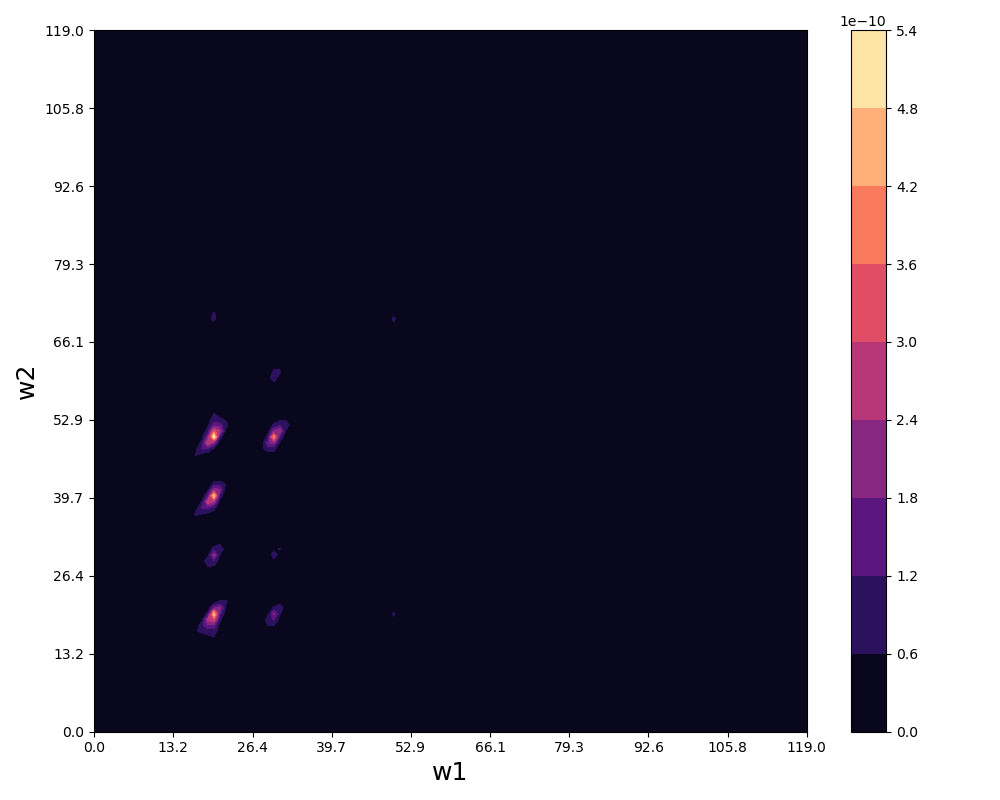

In [5]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

test1 = True
###    Test 1
if test1:
    # set up frequencies for x and y axes
    w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
    funds = {'0': 20, '1': 30
                    , '2': 50
                  }

    # create class instance
    h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=True)

    # get derivatives - mu_Q, mu QQ, alpha_Q, alphaQQ, F_abc
    derivData = h.getDerivs()
    
    # print(derivData)

    # add mechanical and electrical anharmonicities terms and oriantational averages (symbolic setup)
    h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

    # pairs of normal mode indices
    Q_ab = dd_ir.get_abc(2, len(h.fundamentals))
    Q_abc = dd_ir.get_abc(3, len(h.fundamentals))
    
    # plot (and save plot) 2D spectrum
    h.plot2D(Q_ab, Q_abc, figname='test1', w1mw2=False, surface=False)

## Test 1: H2O

In [ ]:
waterBool = True
###    Test 2 (H2O)
if waterBool:
    # set up frequencies for x and y axes
    w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)
    funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))

    # create class instance
    h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False)

    # get derivatives - mu_Q, mu QQ, alpha_Q, alphaQQ, F_abc
    derivData = h.getDerivs(molfile='MOLECULE.INP', rspfile='rsp_tensor')

    # add mechanical and electrical anharmonicities terms and oriantational averages (symbolic setup)
    h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

    # pairs of normal mode indices
    Q_ab = dd_ir.get_abc(2, len(h.fundamentals))
    Q_abc = dd_ir.get_abc(3, len(h.fundamentals))

    # plot (and save plot) 2D spectrum
    h.plot2D(Q_ab, Q_abc, figname='h2o', w1mw2=False, surface=False)

## Test 2: CH3CN

In [ ]:
acetonitrileBool = True
###    Test 2 (CH3CN)
if acetonitrileBool:
    
    # set up frequencies for x and y axes
    w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)
    funds = dict(zip(['0', '1', '2', '3', '4', '5'],
                     [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))
    
    # create class instance
    h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False)
    
    # get derivatives - mu_Q, mu QQ, alpha_Q, alphaQQ, F_abc from the rsp_tensor file
    # includes basis transformation
    dd = h.getDerivs(molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
    
    # add mechanical and electrical anharmonicities terms and oriantational averages (symbolic setup)
    h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

    # pairs of normal mode indices
    Q_ab = dd_ir.get_abc(2, len(h.fundamentals))
    Q_abc = dd_ir.get_abc(3, len(h.fundamentals))

    # plot (and save plot) 2D spectrum
    h.plot2D(Q_ab, Q_abc, figname='ch3cn', w1mw2=False, surface=False)

In [ ]:

#
# electrical_terms = [('a+b,a', 'zero,a')
#                    # ('b,a', 'zero,a')
#                    ]
#
# electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
#                   #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
#                 ]
#
# mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')],
#                      #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
#                      #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')],
#                      #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
#                      #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')],
#                      #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
#                    ]
#
# mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
#                   ]
#
# # electrical_terms, electric_avrg = [], []
# # mechanical_terms, mechanical_avrg = [], []
#
# h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)
#
# coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
# coords_abc = dd_ir.get_abc(3, len(h.fundamentals))
#
# # print(coords_abc)
#
# # h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
# r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
# h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
#
# print(r)

# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)


# Summary of the 2D-IR code

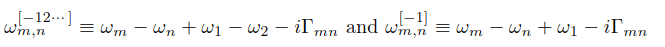

$\omega_1 = \omega_n - \omega_m$


$\omega_2 = \omega_m - \omega_n + \omega_1$

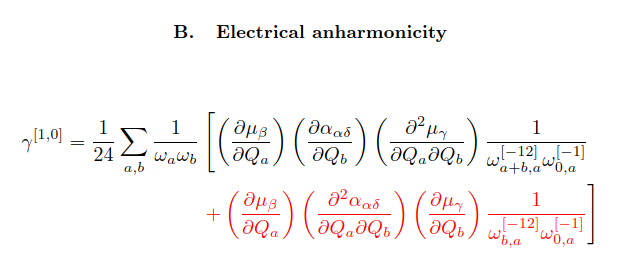

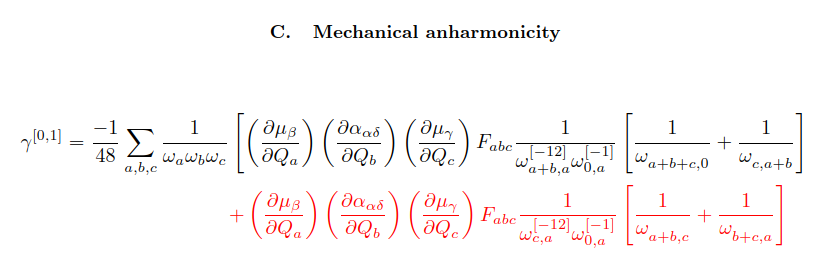

## Building blocks

- $\gamma_{\alpha\beta\delta\gamma}$ - should be averaged over all orientations
    - $\mu_{\beta}$
        - derivatives $\partial Q_a$ and $\partial Q_a \partial Q_b$ - from PyOpenRSP
    - $\alpha_{\alpha\delta}$
        - derivatives $\partial Q_a$ and $\partial Q_a \partial Q_b$ - from PyOpenRSP
    - $\mu_{\gamma}$
        - derivatives $\partial Q_a$ and $\partial Q_a \partial Q_b$ - from PyOpenRSP
    - $F_{abc}$ : derivatives $\partial Q_aQ_bQ_c$
    - $\omega_{m, n} = \omega_m - \omega_n$
    - $\omega_{m, n}^{[-1]} = \omega_m - \omega_n + \omega_1 - i\Gamma_{mn}^{}$
    - $\omega_{m, n}^{[-12..]} = \omega_m - \omega_n + \omega_1 - \omega_2 - i\Gamma_{mn}^{}$

In [1]:
import numpy as np

class Omega:

    def __init__(self, dictFund, m, n=None, sup=0):
        
        # dictFund: dict that maps indices of normal modes to their freqs; numbering starts with 1
        self.dictFund = dictFund

        self.m = m
        self.n = n
        self.sup = sup
        
        
    def comb_w(self):
        
        # if w_{a+b,n} or w_{a+b+c, a}
        if type(self.m) == int:
            self.w_m = self.dictFund[self.m]
            
        # if w_a or w_b or w_c
        else:
            res = 0
            for i in self.m:
                res += self.dictFund[i]
            self.w_m = res
        
        # if w_{a, a+b} or w_{a, a+b+c}
        if self.n is None: 
            self.w_n = None
            
        # if w_a or w_b or w_c
        elif type(self.n)==int:
            self.w_n = self.dictFund[self.n]
        
        else:
            res = 0
            for i in self.n:
                res += self.dictFund[i]
            self.w_n = res
    
    
    # evaluation of w_{m,n}^{-12..} and w_{m,n}
    def evaluate(self, w1=None, w2=None):
        # w1, w2 - meshgrid w1,w2 ?
        
        # getting w_m and w_n
        self.comb_w()
            
        # Gamma is constant, one value for all
        Gamma = 10^3
        
        # if w_{m,n}
        if self.sup == 0 and self.n is None:
            # self.value = self.w_m
            return self.w_m
        
        elif self.sup == 0:
            # self.value = self.w_m - self.w_n
            return self.w_m - self.w_n
        
        # if w_{m,n}^{-1}
        elif self.sup == 1:
            # self.value = self.w_m - self.w_n + w1 - 1j*Gamma
            return self.w_m - self.w_n + w1 - 1j*Gamma
        
        elif self.sup == 2:
            # self.value = self.w_m - self.w_n + w1 - w2 - 1j*Gamma
            return self.w_m - self.w_n + w1 - w2 - 1j*Gamma

In [130]:
funds = {0: 0., 1: 20, 2: 30
                , 3: 50
              }
t = Omega(funds, m=(3, 2,), n=(3,), sup=2)
t.evaluate(20, 50)

-9j

In [134]:
k = Omega(funds, m=(0,), n=(3,), sup=1)
k.evaluate(20)
#print(k.w_m-k.w_n)

(-30-9j)

In [133]:
k = Omega(funds, m=3)
k.evaluate()
#print(k.w_m-k.w_n)

50

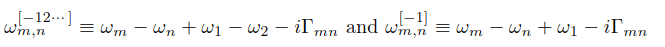

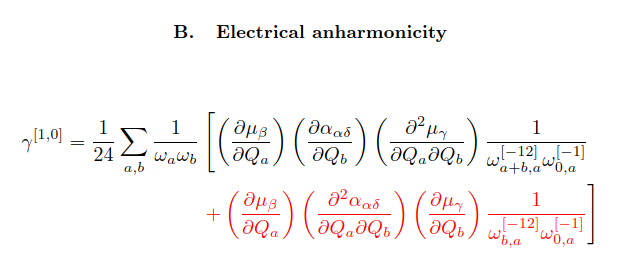

In [4]:
class TermInSum:
    
    def __init__(self, indices, r1, r2, qlist, derivsSet=None, rsp_tensorfile=None):
        """
        indices = 'ab' or 'abc'
        r1 = 'ab,a'
        r2 = '0,a'
        qlist - list of fundamental frequencies
        """
        self.indices = indices
        self.r1 = r1
        self.r2 = r2
        self.derivsSet = derivsSet
        self.rsp_tensorfile = rsp_tensorfile
        
        # lookup table for freqs of normal modes
        vocab = dict(zip(list(range(1,len(qlist)+1)), qlist))
        vocab[0] = 0.
        
        self.indices['0'] = 0.
        
        # part1 = 1/w_a/w_b - CAN BE EVALUATED IMMEDIATELLY for indices
        self.part1 = 1 / Omega(vocab, m=self.indices['a']).evaluate() / Omega(vocab, m=self.indices['b']).evaluate()
        
        # part2 = 1/w_{m,n}^{[-12]}/w_{m,n}^{[-1]} - SHOULD BE JUST A SHELL FOR w1,w2 INPUT
        # self.part2 = 1 / Omega(fundDict, m=r1[0], n=r1[1], sup=2).evaluate(w1, w2) / Omega(fundDict, m=r2[0], n=r2[1], sup=1).evaluate(w1)
        
        self.part2 = lambda w1, w2: 1 / Omega(vocab, m=tuple([self.indices[k] for k in r1.split(',')[0]]), 
                                                     n=tuple([self.indices[k] for k in r1.split(',')[1]]), sup=2).evaluate(w1, w2) / \
            Omega(vocab, m=tuple([self.indices[k] for k in r2.split(',')[0]]), 
                         n=tuple([self.indices[k] for k in r2.split(',')[1]]), sup=1).evaluate(w1)
        
        # part3 = averaged derivatives of (mu,alpha,mu) - CAN BE EVALUATED IMMEDIATELLY
        # self.part3 = averaged(derivsSet)
        
    def evaluate(self, w1, w2):
        """
        qlist - list of fundamental frequencies
        
        """
        
        return self.part1 * self.part2(w1, w2) #* self.part3
    
    

In [189]:
dict(zip([1,2, 3], ['1', '2', '3']))
list('syd')

['s', 'y', 'd']

In [7]:
np.set_printoptions(precision=2)

funds = {0: 0., 1: 20, 2: 30, 3: 50}
qlist = [20, 30, 50]

w1, w2 = np.arange(0., 6, 1.), np.arange(0, 6, 1.)
w1g, w2g = np.meshgrid(w1, w2)

a, b = 1, 2
dct = lambda x, y, z: dict(zip(list(x), [y, z]))
#dict(zip(list(self.indices), [a, b])

q = TermInSum(dct('ab', a, b), 'ab,a', '0,a', qlist)
qq = q.evaluate(w1g, w2g)
# print(qq.shape)
print(qq)

u = TermInSum(dct('ab', a, b), 'b,a', '0,a', qlist)
uu = u.evaluate(w1g, w2g)
# print(qq.shape)
print(uu)

1
[[-2.41e-06+3.18e-07j -2.42e-06+3.91e-07j -2.45e-06+4.69e-07j
  -2.47e-06+5.54e-07j -2.50e-06+6.48e-07j -2.53e-06+7.51e-07j]
 [-2.48e-06+3.04e-07j -2.50e-06+3.81e-07j -2.52e-06+4.62e-07j
  -2.55e-06+5.50e-07j -2.57e-06+6.47e-07j -2.60e-06+7.53e-07j]
 [-2.57e-06+2.88e-07j -2.58e-06+3.68e-07j -2.61e-06+4.53e-07j
  -2.63e-06+5.45e-07j -2.65e-06+6.44e-07j -2.68e-06+7.54e-07j]
 [-2.66e-06+2.70e-07j -2.67e-06+3.53e-07j -2.69e-06+4.42e-07j
  -2.71e-06+5.37e-07j -2.74e-06+6.41e-07j -2.77e-06+7.54e-07j]
 [-2.75e-06+2.47e-07j -2.77e-06+3.35e-07j -2.78e-06+4.28e-07j
  -2.80e-06+5.28e-07j -2.83e-06+6.35e-07j -2.85e-06+7.53e-07j]
 [-2.85e-06+2.21e-07j -2.86e-06+3.14e-07j -2.88e-06+4.12e-07j
  -2.90e-06+5.16e-07j -2.92e-06+6.28e-07j -2.95e-06+7.50e-07j]]
1
[[-5.38e-06-1.72e-06j -5.41e-06-1.34e-06j -5.43e-06-9.88e-07j
  -5.44e-06-6.49e-07j -5.45e-06-3.21e-07j -5.45e-06-0.00e+00j]
 [-5.58e-06-2.12e-06j -5.65e-06-1.69e-06j -5.68e-06-1.28e-06j
  -5.71e-06-9.01e-07j -5.72e-06-5.34e-07j -5.72e-06-1.77e-